Shape: (7043, 21)

First 5 rows:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV Str

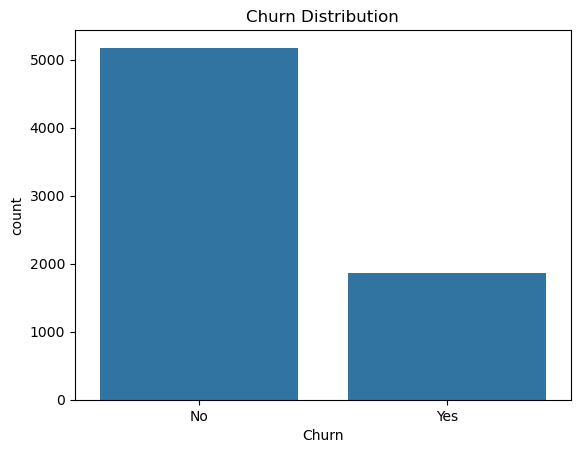

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r'C:\Users\USER\Desktop\telco churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nChurn Distribution:")
print(df['Churn'].value_counts())

sns.countplot(x='Churn', data=df)
plt.title('Churn Distribution')
plt.show()

In [15]:
data= pd.read_csv(r'C:\Users\USER\Desktop\telco churn\data\WA_Fn-UseC_-Telco-Customer-Churn.csv')
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


In [8]:
print(df.isnull().sum())

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [9]:
mask = df['TotalCharges'].str.strip() == ''
print("Rows with spaces in TotalCharges:", mask.sum())
print(df[mask][['customerID', 'TotalCharges', 'tenure', 'MonthlyCharges']])

Rows with spaces in TotalCharges: 11
      customerID TotalCharges  tenure  MonthlyCharges
488   4472-LVYGI                    0           52.55
753   3115-CZMZD                    0           20.25
936   5709-LVOEQ                    0           80.85
1082  4367-NUYAO                    0           25.75
1340  1371-DWPAZ                    0           56.05
3331  7644-OMVMY                    0           19.85
3826  3213-VVOLG                    0           25.35
4380  2520-SGTTA                    0           20.00
5218  2923-ARZLG                    0           19.70
6670  4075-WKNIU                    0           73.35
6754  2775-SEFEE                    0           61.90


In [10]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [11]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [16]:
from sklearn.preprocessing import LabelEncoder

# Fix TotalCharges - convert text to number, blanks become NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Fill the 11 NaN rows with 0 (brand new customers, no charges yet)
df['TotalCharges'].fillna(0, inplace=True)

# Drop customerID - not useful for prediction
df = df.drop('customerID', axis=1)

# Encode all text columns into numbers
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# Confirm everything is now numeric
print(df.dtypes)
print("\nMissing values after cleaning:", df.isnull().sum().sum())
print("\nPreprocessing complete!")

gender                int64
SeniorCitizen         int64
Partner               int64
Dependents            int64
tenure                int64
PhoneService          int64
MultipleLines         int64
InternetService       int64
OnlineSecurity        int64
OnlineBackup          int64
DeviceProtection      int64
TechSupport           int64
StreamingTV           int64
StreamingMovies       int64
Contract              int64
PaperlessBilling      int64
PaymentMethod         int64
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

Missing values after cleaning: 0

Preprocessing complete!


C:\Users\USER\AppData\Local\Temp\ipykernel_10084\1620002790.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(0, inplace=True)


In [17]:
from sklearn.model_selection import train_test_split

# Split into features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)
print("\nTraining target distribution:")
print(y_train.value_counts())
print("\nTest target distribution:")
print(y_test.value_counts())
print("\nTrain/Test Split complete! ")

Training set size: (5634, 19)
Test set size: (1409, 19)

Training target distribution:
Churn
0    4138
1    1496
Name: count, dtype: int64

Test target distribution:
Churn
0    1036
1     373
Name: count, dtype: int64

Train/Test Split complete! ✅


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import joblib

# Train Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
print("Logistic Regression Accuracy:", round(lr.score(X_test, y_test) * 100, 2), "%")

# Train Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("Random Forest Accuracy:", round(rf.score(X_test, y_test) * 100, 2), "%")

# Save the best model
joblib.dump(rf, 'model.pkl')
print("\nModel saved as model.pkl ✅")

C:\Users\USER\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy: 81.55 %
Random Forest Accuracy: 79.49 %

Model saved as model.pkl ✅


In [19]:
from sklearn.preprocessing import StandardScaler

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Retrain Logistic Regression on scaled data
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)
print("Logistic Regression Accuracy (scaled):", round(lr.score(X_test_scaled, y_test) * 100, 2), "%")

# Retrain Random Forest on scaled data
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
print("Random Forest Accuracy (scaled):", round(rf.score(X_test_scaled, y_test) * 100, 2), "%")

# Save the best model and scaler
joblib.dump(rf, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print("\nModels saved! ✅")

Logistic Regression Accuracy (scaled): 81.55 %
Random Forest Accuracy (scaled): 79.56 %

Models saved! ✅


Classification Report:
              precision    recall  f1-score   support

    No Churn       0.86      0.90      0.88      1036
       Churn       0.68      0.58      0.62       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



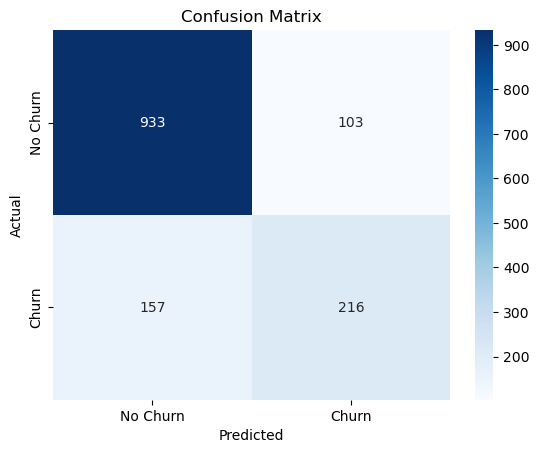

ROC AUC Score: 0.8614


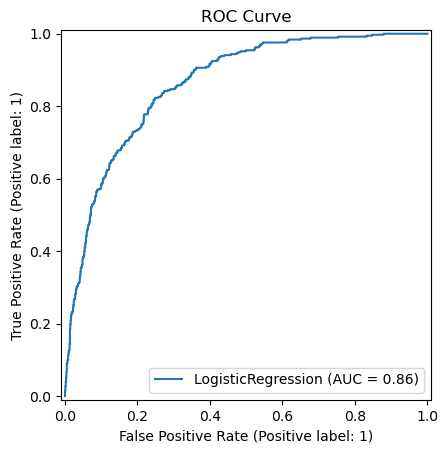

In [20]:
from sklearn.metrics import (classification_report, 
    confusion_matrix, roc_auc_score, RocCurveDisplay)

# Use Logistic Regression as our best model
y_pred = lr.predict(X_test_scaled)

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC AUC Score
roc_score = roc_auc_score(y_test, lr.predict_proba(X_test_scaled)[:,1])
print(f"ROC AUC Score: {round(roc_score, 4)}")

# ROC Curve
RocCurveDisplay.from_estimator(lr, X_test_scaled, y_test)
plt.title('ROC Curve')
plt.show()